## AGN Homework 1 – SDSS Database

The **Sloan Digital Sky Survey (SDSS)** is a cornerstone of modern observational cosmology and extragalactic astrophysics, providing the largest and most detailed threedimensional maps of the universe. It is indispensable in the study of **Active Galactic Nuclei (AGN)** because its widefield multifilter imaging and extensive spectroscopic followup have enabled the discovery and systematic classification of hundreds of thousands of quasars across a vast range of redshifts. Its database allows researchers to perform complex `SQL` queries to correlate multiwavelength photometric data with spectroscopic line measurements. This infrastructure supports the statistical study of the main sequence of active galactic cores, the evolution of supermassive black holes, and the relationship between central engines and their host galaxies.

In [1]:
%%capture

import pandas as pd
import numpy as np
import matplotlib as mpl

import matplotlib.pyplot as plt

from astroquery.sdss import SDSS

from astropy.io import fits
from astropy.table import Table

### [a)](https://skyserver.sdss.org/dr19/SearchTools/sql)

#### Task:

- select galaxies & quasars
- filter redshifts *0.05 < z < 0.3*
- ensure *SNR > 35* near *Hβ* line (band *g λ4000-5500* range)
- emission lines present
  - *[O III] λ5007*
  - *Hβ λ4863*
  - *Hγ λ4341*
- require *FWHM > 1000 km/s* for *Hβ*
- find flux ratios
  - *[O III] / Hβ*
  - *Hβ / Hγ*
  - *[O III] / Hγ*
- for *Hβ* search
  - equivalent width
  - flux
  - redshift
  - type *SFD* extinction correction *E(B-V)*

#### Query:

```sql
SELECT 
    (g.oiii_5007_flux / g.h_beta_flux) AS oiii_hbeta_ratio,
    (g.h_beta_flux / g.h_gamma_flux) AS hbeta_hgamma_ratio,
    (g.oiii_5007_flux / g.h_gamma_flux) AS oiii_hgamma_ratio,
    g.h_beta_eqw, 
    g.h_beta_flux, 
    s.z, 
    i.e_bv_sfd -- E(B-V) SFD extinction correction
FROM SpecObj AS s
JOIN galSpecLine AS g ON s.specobjid = g.specobjid
JOIN galSpecInfo AS i ON s.specobjid = i.specobjid
WHERE (s.class = 'QSO' OR s.class = 'GALAXY') 
  AND s.z BETWEEN 0.05 AND 0.3
  AND s.snmedian_g > 35
  AND g.oiii_5007_eqw < 0 
  AND g.h_beta_eqw < 0 
  AND g.h_gamma_eqw < 0
  AND g.h_beta_flux > 0
  AND g.h_gamma_flux > 0
  AND (2.355 * g.sigma_balmer) > 1000
```

#### Result:

In [2]:
sql = '''SELECT 
    (g.oiii_5007_flux / g.h_beta_flux) AS oiii_hbeta_ratio,
    (g.h_beta_flux / g.h_gamma_flux) AS hbeta_hgamma_ratio,
    (g.oiii_5007_flux / g.h_gamma_flux) AS oiii_hgamma_ratio,
    g.h_beta_eqw, 
    g.h_beta_flux, 
    s.z, 
    i.e_bv_sfd -- E(B-V) SFD extinction correction
FROM SpecObj AS s
JOIN galSpecLine AS g ON s.specobjid = g.specobjid
JOIN galSpecInfo AS i ON s.specobjid = i.specobjid
WHERE (s.class = 'QSO' OR s.class = 'GALAXY') 
  AND s.z BETWEEN 0.05 AND 0.3
  AND s.snmedian_g > 35
  AND g.oiii_5007_eqw < 0 
  AND g.h_beta_eqw < 0 
  AND g.h_gamma_eqw < 0
  AND g.h_beta_flux > 0
  AND g.h_gamma_flux > 0
  AND (2.355 * g.sigma_balmer) > 1000'''

table = SDSS.query_sql(sql)

In [3]:
df_tab = table.to_pandas()

df_tab.to_csv('a_tab.csv', index=False)

df_tab = df_tab.sort_values(by='z')
df_tab.head(10).style.hide()

oiii_hbeta_ratio,hbeta_hgamma_ratio,oiii_hgamma_ratio,h_beta_eqw,h_beta_flux,z,e_bv_sfd
0.838593,2.109372,1.768904,-22.883050,3397.969000,0.050148,0.028808
0.475455,2.312229,1.099362,-0.807589,86.449180,0.050155,0.047332
0.642544,2.033772,1.306788,-28.080860,3685.079000,0.050264,0.068898
0.266649,2.234088,0.595717,-28.283150,1813.709000,0.050270,0.026077
1.879409,1.322198,2.484950,-0.030921,12.287830,0.050316,0.019036
0.777271,0.901040,0.700352,-0.336358,35.005860,0.050468,0.010763
0.680949,1.514910,1.031576,-0.746623,71.214100,0.050600,0.046143
1.035149,1.135655,1.175573,-0.695808,77.767630,0.050696,0.023242
0.964936,0.955046,0.921559,-0.469935,50.469870,0.050766,0.024365
0.483596,1.837952,0.888826,-0.366475,39.748220,0.051004,0.044673


In [4]:
df_web = pd.read_csv('a_web.csv', skiprows=1)

df_web = df_web.sort_values(by='z')
df_web.head(10).style.hide()

oiii_hbeta_ratio,hbeta_hgamma_ratio,oiii_hgamma_ratio,h_beta_eqw,h_beta_flux,z,e_bv_sfd
0.838593,2.109372,1.768904,-22.883050,3397.969000,0.050148,0.028808
0.475455,2.312229,1.099362,-0.807589,86.449180,0.050155,0.047332
0.642544,2.033772,1.306788,-28.080860,3685.079000,0.050264,0.068898
0.266649,2.234088,0.595717,-28.283150,1813.709000,0.050270,0.026077
1.879409,1.322198,2.484950,-0.030921,12.287830,0.050316,0.019036
0.777271,0.901040,0.700352,-0.336358,35.005860,0.050468,0.010763
0.680949,1.514910,1.031576,-0.746623,71.214100,0.050600,0.046143
1.035149,1.135655,1.175573,-0.695808,77.767630,0.050696,0.023242
0.964936,0.955046,0.921559,-0.469935,50.469870,0.050766,0.024365
0.483596,1.837952,0.888826,-0.366475,39.748220,0.051004,0.044673


### [b)](https://skyserver.sdss.org/dr19/SearchTools/sql)

#### Task:

- count found objects
- determine which condition causes most severe narrowing

#### Query:

```sql
SELECT 
    count(*)
FROM SpecObj AS s
JOIN galSpecLine AS g ON s.specobjid = g.specobjid
JOIN galSpecInfo AS i ON s.specobjid = i.specobjid
WHERE (s.class = 'QSO' OR s.class = 'GALAXY') 
  AND s.z BETWEEN 0.05 AND 0.3
  AND s.snmedian_g > 35
  AND g.oiii_5007_eqw < 0 
  AND g.h_beta_eqw < 0 
  AND g.h_gamma_eqw < 0
  AND g.h_beta_flux > 0
  AND g.h_gamma_flux > 0
  AND (2.355 * g.sigma_balmer) > 1000
```

#### Method:

- sequentially comment out conditions via `--`

#### Result:

- *225* with all filters
- *405 (Δ180)* without `fwhm(g.sigma_balmer) > 1000`
- *227 (Δ2)* without `g.h_gamma_flux > 0`
- *229 (Δ4)* without `g.h_beta_flux > 0`
- *225 (Δ0)* without `g.h_gamma_eqw < 0`
- *225 (Δ0)* without `g.h_beta_eqw < 0`
- *227 (Δ2)* without `g.oiii_5007_eqw < 0 `
- *22350 (Δ22125)* without `s.snmedian_g > 35`
- *1436 (Δ1211)* without `0.05 < s.z < 0.3`

#### Conclusion:

- our *SNR* constraint is the most selective out of all conditions

### [c)](https://skyserver.sdss.org/dr19/SearchTools/sql)

#### Task:

- check for entires with subclass of active galactic nuclei

#### Query:

```sql
SELECT 
    (g.oiii_5007_flux / g.h_beta_flux) AS oiii_hbeta_ratio,
    (g.h_beta_flux / g.h_gamma_flux) AS hbeta_hgamma_ratio,
    (g.oiii_5007_flux / g.h_gamma_flux) AS oiii_hgamma_ratio,
    g.h_beta_eqw, 
    g.h_beta_flux, 
    s.z, 
    i.e_bv_sfd -- E(B-V) SFD extinction correction
FROM SpecObj AS s
JOIN galSpecLine AS g ON s.specobjid = g.specobjid
JOIN galSpecInfo AS i ON s.specobjid = i.specobjid
WHERE s.subclass = 'AGN' 
  AND s.z BETWEEN 0.05 AND 0.3
  AND s.snmedian_g > 35
  AND g.oiii_5007_eqw < 0 
  AND g.h_beta_eqw < 0 
  AND g.h_gamma_eqw < 0
  AND g.h_beta_flux > 0
  AND g.h_gamma_flux > 0
  AND (2.355 * g.sigma_balmer) > 1000
```

#### Result:

- none found

### [d)](https://skyserver.sdss.org/dr18/CrossMatchTools/ObjectCrossID) 

#### Task:

- modify selection for *0.05 < z < 0.6*
- cross identify with provided spectrum list

#### Query:

```sql
SELECT 
    s.specobjid, s.ra, s.dec, s.plate, s.mjd, s.fiberid
FROM #upload AS u
JOIN SpecObjAll AS s ON (s.plate=u.up_plate AND s.mjd=u.up_mjd AND s.fiberID=u.up_fiber)
JOIN galSpecLine AS g ON s.specobjid = g.specobjid
JOIN galSpecInfo AS i ON s.specobjid = i.specobjid
WHERE (s.class = "QSO" OR s.class = "GALAXY")
  AND s.z BETWEEN 0.05 AND 0.6
  AND s.snmedian_g > 35
  AND g.oiii_5007_eqw < 0 
  AND g.h_beta_eqw < 0 
  AND g.h_gamma_eqw < 0
  AND g.h_beta_flux > 0
  AND g.h_gamma_flux > 0
  AND (2.355 * g.sigma_balmer) > 1000
```

#### Result:

In [5]:
df_raw = pd.read_csv('d_raw.csv', skiprows=1)
df_fil = pd.read_csv('d_fil.csv', skiprows=1)

print(f'found {len(df_fil):.0f}/{len(df_raw):.0f} matches')

def style(row):
    match = (df_fil == row.values).all(axis=1).any()
    color = 'background-color: #c6efce' if match else 'background-color: #ffc7ce'
    return [color] * len(row)

df_raw.tail(30).style.apply(style, axis=1).hide()

found 47/287 matches


specobjid,ra,dec,plate,mjd,fiberid
1131671838481475584,147.503090,48.524815,1005,52703,518
1431145825085450240,133.760240,32.655112,1271,52974,462
2844134292232103936,241.913770,10.598803,2526,54582,404
1107990827541489664,314.035330,0.491143,984,52442,383
1974917553834715136,171.679250,15.765243,1754,53385,324
1852249985752524800,218.798050,36.077014,1645,53172,526
2371181000249075712,166.028950,31.686528,2106,53714,130
3112001987126781952,224.578290,15.182772,2764,54535,53
2022278750695090176,198.144340,9.962635,1796,53884,591
2804686001853720576,166.812690,16.467308,2491,53855,252


### e)

#### Task:

- verify found spectra
- download from server

#### Result:

In [6]:
import os

for PLATE, MJD, FIBERID in zip(df_fil['plate'], df_fil['mjd'], df_fil['fiberid']):
    FILE = f'{PLATE:04d}-{MJD}-{FIBERID:04d}.fits'
    PATH = f'spec/{FILE}'
    URL = f'https://dr18.sdss.org/sas/dr18/spectro/sdss/redux/26/spectra/{PLATE:04d}/spec-{FILE}'

    if os.path.exists(PATH):
        print(f'{PATH[:19]} skipping, already exists')
        continue
    
    !wget -q --show-progress {URL} -O {PATH}

spec/0637-52174-025 skipping, already exists
spec/0976-52413-057 skipping, already exists
spec/2520-54584-044 skipping, already exists
spec/0555-52266-007 skipping, already exists
spec/0411-51817-038 skipping, already exists
spec/1224-52765-037 100%[===================>] 590.62K   506KB/s    in 1.2s    
spec/1716-53827-035 100%[===================>] 731.25K   865KB/s    in 0.8s    
spec/2347-53757-015 skipping, already exists
spec/1810-53794-050 100%[===================>] 731.25K   861KB/s    in 0.8s    
spec/2034-53466-023 skipping, already exists
spec/1754-53385-032 100%[===================>] 590.62K   705KB/s    in 0.8s    
spec/2173-53874-035 skipping, already exists
spec/0640-52178-051 skipping, already exists
spec/1843-53816-058 100%[===================>] 731.25K  1.01MB/s    in 0.7s    
spec/2646-54479-020 skipping, already exists
spec/0268-51633-023 skipping, already exists
spec/0795-52378-052 skipping, already exists
spec/2645-54477-013 skipping, already exists
spec/0793-52370

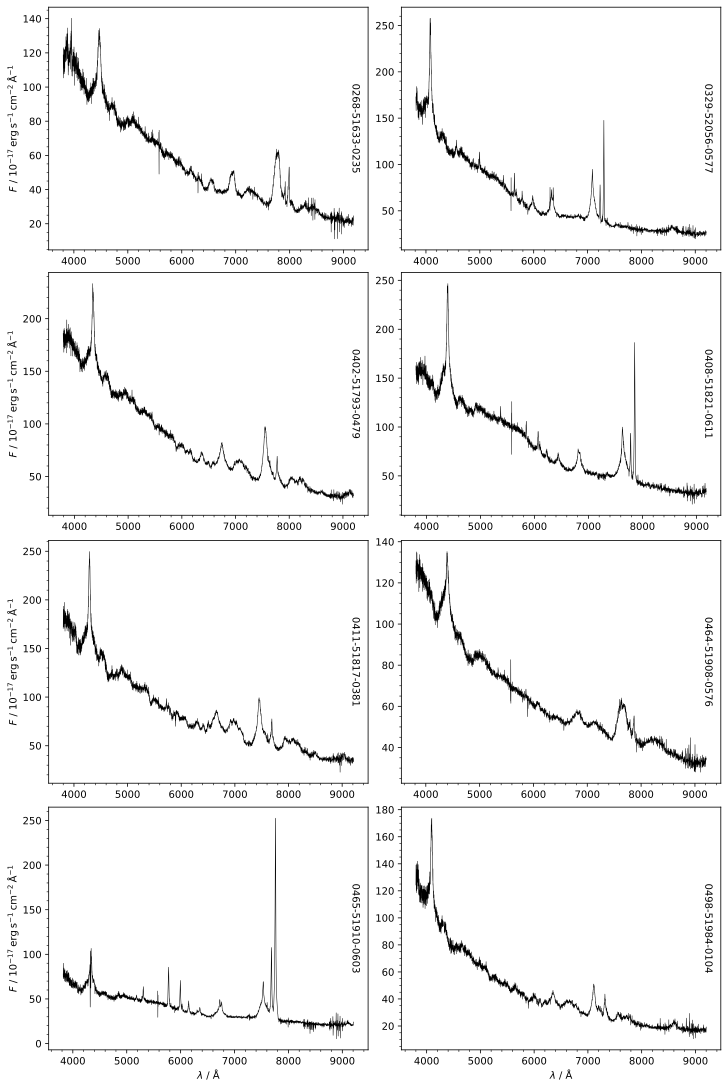

In [7]:
%matplotlib inline
%config InlineBackend.figure_formats = ['svg']

plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['legend.frameon'] = False
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

specs = ['0268-51633-0235',
         '0329-52056-0577',
         '0402-51793-0479',
         '0408-51821-0611',
         '0411-51817-0381',
         '0464-51908-0576',
         '0465-51910-0603',
         '0498-51984-0104']

fig, axs = plt.subplots(4, 2, figsize=[10,15])
axs = axs.flatten()

i = 0

for spec in specs:
    with fits.open(f'spec/{spec}.fits') as hdul:

        data = hdul[1].data

        flux = data['flux']
        loglam = data['loglam']

    axs[i].plot(10**loglam, flux, 'k-', lw=0.5)
    axs[i].text(0.96, 0.5, f'{spec}', rotation=270, va='center', ha='center', transform=axs[i].transAxes)

    match i:
        case 0 | 2 | 4:
            axs[i].set_ylabel('$F$ / 10$^{-17}$ erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$')
        case 6:
            axs[i].set_xlabel(r'$\lambda$ / Å')
            axs[i].set_ylabel('$F$ / 10$^{-17}$ erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$')
        case 7:
            axs[i].set_xlabel(r'$\lambda$ / Å')
        case _:
            pass
    
    i += 1

plt.show()
plt.close()